# Lecture 04 — Car-type recommendation

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Classification · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Predict a broad vehicle category from a simulated buyer profile; compare class-wise errors.

## Practical problem
An imaginary showroom wants to suggest Compact, Sedan or SUV categories based on budget, family size, travel and preferences. No model can replace vehicle safety, price or suitability checks.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The suggested categories are based on fabricated preference rules and random variation; not genuine customer choices.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 600 rows × 6 columns


,budget_omr,family_size,daily_commute_km,offroad_interest,fuel_saving_priority,suggested_category
0,24869.0,7,52.7,0.15,0.30,SUV
1,4254.0,7,43.8,0.30,0.07,Compact
2,4225.0,1,81.4,0.90,0.13,SUV
3,10638.0,4,10.0,0.90,0.47,SUV
4,21573.0,2,112.9,0.62,0.08,SUV


In [ ]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['budget_omr', 'family_size', 'daily_commute_km', 'offroad_interest', 'fuel_saving_priority', 'suggested_category']
Missing values per column:
budget_omr              0
family_size             0
daily_commute_km        0
offroad_interest        0
fuel_saving_priority    0
suggested_category      0


## 2. Visualise and formulate the task
**Question:** Which available columns are inputs (features), and which column is the class label? A classification problem predicts a *category*, not a continuous number.

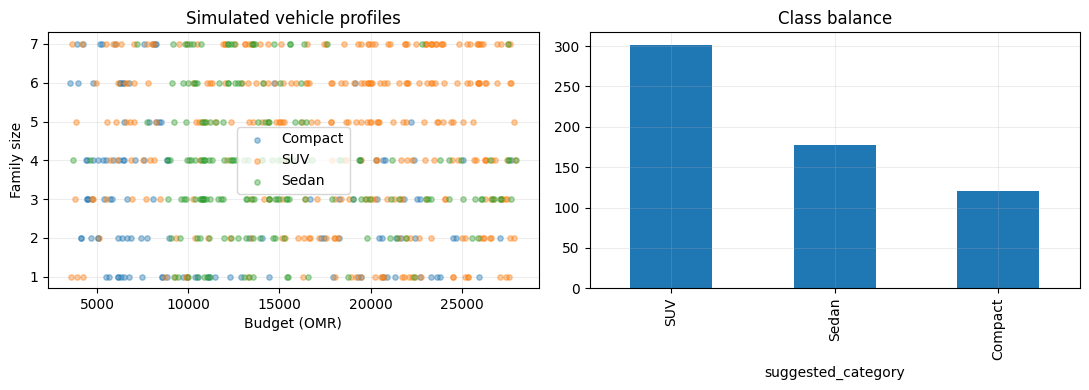

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for label,group in df.groupby('suggested_category'):
    ax[0].scatter(group['budget_omr'],group['family_size'],alpha=.4,label=label,s=15)
ax[0].set(xlabel='Budget (OMR)',ylabel='Family size',title='Simulated vehicle profiles');ax[0].legend()
df['suggested_category'].value_counts().plot.bar(ax=ax[1]);ax[1].set_title('Class balance');plt.tight_layout();plt.show()

## 3. Prepare training and test data
The training set teaches the model. The test set simulates **unseen** examples. Split before fitting preprocessing transformations to avoid data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
X = df[['budget_omr', 'family_size', 'daily_commute_km', 'offroad_interest', 'fuel_saving_priority']]
y = df['suggested_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)
print('Train:', len(X_train), 'Test:', len(X_test)); print(y.value_counts())

Train: 450 Test: 150
suggested_category
SUV        302
Sedan      178
Compact    120
Name: count, dtype: int64


## 4. Train the selected algorithm
A **decision tree** is interpretable: it repeatedly asks feature-based questions and assigns a class at each leaf. A shallow tree avoids memorising simulated details.

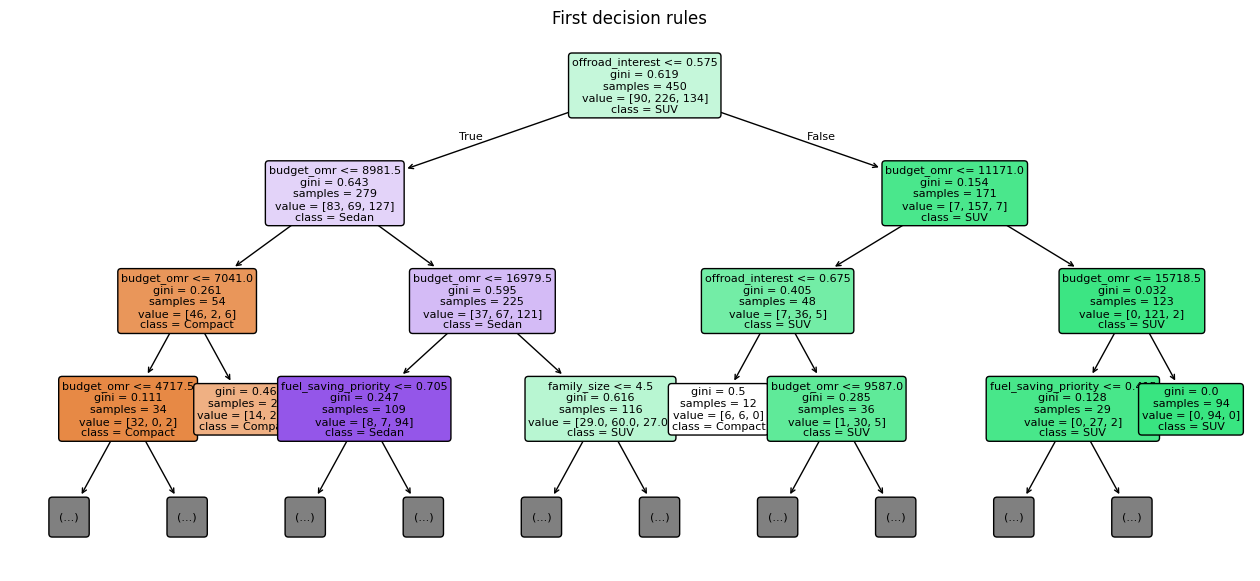

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model=DecisionTreeClassifier(max_depth=5,min_samples_leaf=12,random_state=42)
model.fit(X_train,y_train)
plt.figure(figsize=(16,7));plot_tree(model,feature_names=X.columns, class_names=model.classes_,filled=True,rounded=True,fontsize=8,max_depth=3);plt.title('First decision rules');plt.show()

## 5. Evaluate the classifier
**Accuracy** is the share of correct predictions; **precision** asks how often predicted members of a class truly belong to it; **recall** asks how many true members are found. For multiclass examples we also report macro averages. The **confusion matrix** shows which categories are being mixed up.

Accuracy: 0.827
Precision (macro): 0.81
Recall (macro): 0.824
F1 (macro): 0.816
              precision    recall  f1-score   support

     Compact       0.78      0.83      0.81        30
         SUV       0.89      0.84      0.86        76
       Sedan       0.76      0.80      0.78        44

    accuracy                           0.83       150
   macro avg       0.81      0.82      0.82       150
weighted avg       0.83      0.83      0.83       150



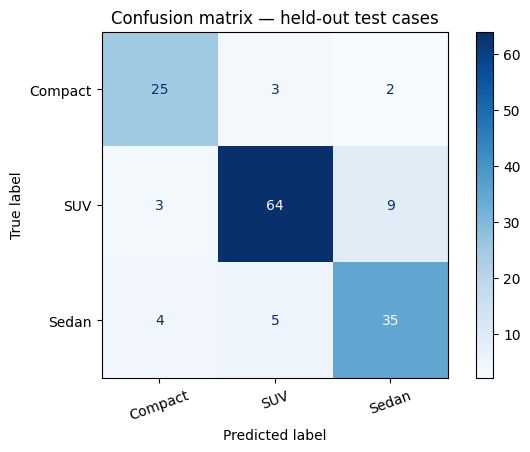

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
print('Accuracy:', round(accuracy_score(y_test,y_pred),3))
print('Precision (macro):',round(precision_score(y_test,y_pred,average='macro',zero_division=0),3))
print('Recall (macro):',round(recall_score(y_test,y_pred,average='macro',zero_division=0),3))
print('F1 (macro):',round(f1_score(y_test,y_pred,average='macro',zero_division=0),3))
print(classification_report(y_test,y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues',xticks_rotation=20)
plt.title('Confusion matrix — held-out test cases'); plt.grid(False); plt.show()

## 6. Make predictions on new, unseen inputs
These are intentionally invented examples. Interpret the output as a demonstration of how a trained model is used, **not** a real-world recommendation.

In [ ]:
new_buyers=pd.DataFrame([{'budget_omr':6000,'family_size':2,'daily_commute_km':45,'offroad_interest':.05,'fuel_saving_priority':.95},{'budget_omr':19000,'family_size':6,'daily_commute_km':35,'offroad_interest':.85,'fuel_saving_priority':.20},{'budget_omr':13000,'family_size':3,'daily_commute_km':90,'offroad_interest':.15,'fuel_saving_priority':.50}])
new_buyers['suggested_category']=model.predict(new_buyers)
display(new_buyers)

,budget_omr,family_size,daily_commute_km,offroad_interest,fuel_saving_priority,suggested_category
0,6000,2,45,0.05,0.95,Compact
1,19000,6,35,0.85,0.20,SUV
2,13000,3,90,0.15,0.50,Sedan


## Student investigation and discussion
1. Which input features appear most influential in the tree?
2. Would a classification score justify a real purchase? Why not?
3. Which false recommendation could inconvenience a family most?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.